In [1]:
import warnings
import numpy as np # for mathematical operrations
import pandas as pd
import plotly.express as px  # for visualisatons
import plotly. graph_objects as go  # for one of the visualisations
from sklearn.impute import SimpleImputer # for imputing missing values
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline,make_pipeline # combine things from sklearn



In [2]:
def wrangle(filepath):
    # read csv file into DataFrame
    df= pd.read_csv(filepath)

    #subset to properties that are in Capital federal
    mask_ba = df['place_with_parent_names'].str.contains('Capital Federal')
    
    #subset to properties that are apartments
    mask_apt= df['property_type'] == 'apartment'

    # subset to properties less than $400,000 USD
    mask_price= df['price_aprox_usd'] < 400_000

    

    df = df[mask_ba & mask_apt & mask_price]

    # subset outliers by `surface_covered_in_m2`
    low,high= df['surface_covered_in_m2'].quantile([0.1,0.9])
    mask_area= df['surface_covered_in_m2'].between(low,high)
    df= df[mask_area]

    #split the 'lat-lon' column
    df[['lat','lon']]= df['lat-lon'].str.split(',', expand=True).astype(float)
    df.drop(columns='lat-lon',inplace=True)
    
    return df



In [3]:
frame1= wrangle(r"C:\Users\Peace\OneDrive\WP projects\HOUSING IN BUENOS AIRES 2\Bueinos-Aires-Real_estate-1 - Sheet1.csv")
print(frame1.info())
frame1.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1343 entries, 4 to 8604
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   1343 non-null   object 
 1   property_type               1343 non-null   object 
 2   place_with_parent_names     1343 non-null   object 
 3   price                       1343 non-null   float64
 4   currency                    1343 non-null   object 
 5   price_aprox_local_currency  1343 non-null   float64
 6   price_aprox_usd             1343 non-null   float64
 7   surface_total_in_m2         965 non-null    float64
 8   surface_covered_in_m2       1343 non-null   float64
 9   price_usd_per_m2            927 non-null    float64
 10  price_per_m2                1343 non-null   float64
 11  floor                       379 non-null    float64
 12  rooms                       1078 non-null   float64
 13  expenses                    349 non-nu

,operation,property_type,place_with_parent_names,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,index,lat,lon
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,5,-34.584651,-58.454693
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,10,-34.638979,-58.500115
29,sell,apartment,|Argentina|Capital Federal|Caballito|,118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,30,-34.615847,-58.459957
40,sell,apartment,|Argentina|Capital Federal|Constitución|,57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,41,-34.625222,-58.382382
41,sell,apartment,|Argentina|Capital Federal|Once|,90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,42,-34.610610,-58.412511


for this model we consider the apartment location. however the latitude and longitude data is joined in one column and is of object rather than float.

In [4]:
frame1[['lat','lon']]= frame1['lat-lon'].str.split(',',expand=True).astype(float)
frame1.drop(columns= 'lat-lon',inplace=True)
frame1.info()

KeyError: 'lat-lon'

now that thee wrangle function works, we use it to clean and import more data.

In [60]:
frame2=wrangle(r"C:\Users\Peace\OneDrive\WP projects\HOUSING IN BUENOS AIRES 2\Bueinos-Aires-Real_estate-2 - Sheet1.csv")


we now need to combine(concatenate) the dataframes

In [7]:
df= pd.concat([frame1,frame2], ignore_index=True)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658 entries, 0 to 2657
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   2658 non-null   object 
 1   property_type               2658 non-null   object 
 2   place_with_parent_names     2658 non-null   object 
 3   price                       2658 non-null   float64
 4   currency                    2658 non-null   object 
 5   price_aprox_local_currency  2658 non-null   float64
 6   price_aprox_usd             2658 non-null   float64
 7   surface_total_in_m2         1898 non-null   float64
 8   surface_covered_in_m2       2658 non-null   float64
 9   price_usd_per_m2            1818 non-null   float64
 10  price_per_m2                2658 non-null   float64
 11  floor                       769 non-null    float64
 12  rooms                       2137 non-null   float64
 13  expenses                    688 n

,operation,property_type,place_with_parent_names,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,index,lat,lon,Index
0,sell,apartment,|Argentina|Capital Federal|Chacarita|,129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,5.0,-34.584651,-58.454693,NaN
1,sell,apartment,|Argentina|Capital Federal|Villa Luro|,87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,10.0,-34.638979,-58.500115,NaN
2,sell,apartment,|Argentina|Capital Federal|Caballito|,118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,30.0,-34.615847,-58.459957,NaN
3,sell,apartment,|Argentina|Capital Federal|Constitución|,57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364,http://constitucion.properati.com.ar/k2f0_vent...,41.0,-34.625222,-58.382382,NaN
4,sell,apartment,|Argentina|Capital Federal|Once|,90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450,http://once.properati.com.ar/suwa_venta_depart...,42.0,-34.610610,-58.412511,NaN


## Explore 

we need to show the longitude, latitude and the price in a 2 dimensional screen

In [24]:
import plotly.express as px

fig = px.scatter_mapbox(
    df,                          # your DataFrame
    lat="lat",                   # column with latitude
    lon="lon",                   # column with longitude
    color="price_aprox_usd",     # column that sets each dot's colour
    width=600,
    height=600,
    hover_data=["price_aprox_usd"],     # shows the price when you hover over a dot
    color_continuous_scale="Viridis",   # colour gradient: dark = low, yellow = high
)

fig.update_layout(mapbox_style="open-street-map")  # free map background, no API key needed
fig.show()

C:\Users\Peace\AppData\Local\Temp\ipykernel_14720\399317719.py:3: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



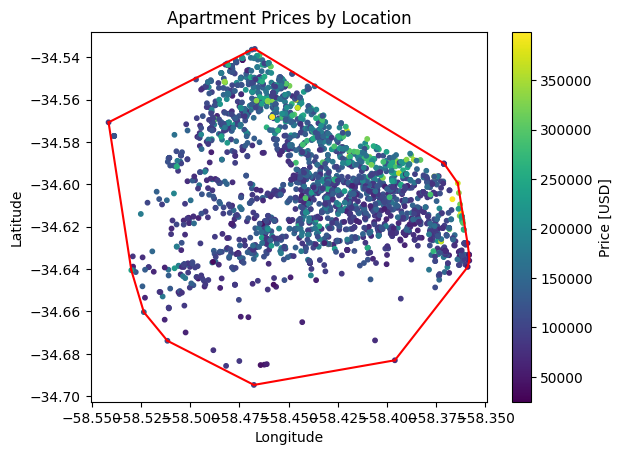

In [11]:
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

# Get the coordinates as an array of (lon, lat) pairs
points = df[["lon", "lat"]].dropna().values

# Find the outer boundary of the points
hull = ConvexHull(points)

plt.scatter(df["lon"], df["lat"], c=df["price_aprox_usd"], cmap="viridis", s=10)
plt.colorbar(label="Price [USD]")

# Draw a line along each edge of the boundary
for edge in hull.simplices:
    plt.plot(points[edge, 0], points[edge, 1], color="red", linewidth=1.5)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Apartment Prices by Location")
plt.show()

a 3D scatter plot 

In [25]:
fig = px.scatter_3d(
    df,
    x="lon",                    # longitude on the x-axis
    y="lat",                    # latitude on the y-axis
    z="price_aprox_usd",        # price on the z-axis (height)
    labels={"lon": "Longitude", "lat": "Latitude", "price_aprox_usd": "Price"},
    width=600,
    height=500,
)

fig.update_traces(
    marker={"size": 4, "line": {"width": 2, "color": "DarkSlateGrey"}},
    selector={"mode": "markers"},
)

fig.show()

#### split
split the data into the feature matrix( longitude and latitude ) and the target vector (price)

In [17]:
# the feature matrix
features=['lon','lat']
X_train= df[features]
print(X_train.shape)
print(X_train.head(10))

(2658, 2)
         lon        lat
0 -58.454693 -34.584651
1 -58.500115 -34.638979
2 -58.459957 -34.615847
3 -58.382382 -34.625222
4 -58.412511 -34.610610
5 -58.427291 -34.603824
6 -58.423963 -34.586103
7 -58.472463 -34.626518
8 -58.456686 -34.562084
9 -58.524277 -34.648143


In [20]:
# the target vector
target='price_aprox_usd'
y_train=df[target]
print(y_train.shape)
print(y_train.head(10))


(2658,)
0    129000.0
1     87000.0
2    118000.0
3     57000.0
4     90000.0
5    138000.0
6    114000.0
7     82000.0
8    166000.0
9    136500.0
Name: price_aprox_usd, dtype: float64


## Model Building
#### Baseline model
a baseline is needed inorder to be able to evaluate the model's performance. The y_mean is definetly not the same as the previous project because we added the number of observations in the training data. the baseline model, will predict the mean over and over again. 

- the baseline gives you a score to beat.if the real model cannot do better than the baseline model then it has not learned anything useful from the location

In [ ]:
y_mean= y_train.mean()
y_mean

np.float64(134732.97340481562)

In [23]:
y_pred_baseline= [y_mean] * len(y_train)
y_pred_baseline[:5]

[np.float64(134732.97340481562),
 np.float64(134732.97340481562),
 np.float64(134732.97340481562),
 np.float64(134732.97340481562),
 np.float64(134732.97340481562)]

In [26]:
mae_baseline= mean_absolute_error(y_train,y_pred_baseline)

print(f'Mean apartment Price {round(y_mean,2)}')
print(f'Baseline MAE {round(mae_baseline,2)}')

Mean apartment Price 134732.97
Baseline MAE 45422.75


- if we are to predict 134732.97$ as the price of every apartment regardless of the location then on average out predictions would be off by 45,422.75

using df.info() we find that there are missing values. because of the math, a linear regression model can't handle observations where there are missing values. in the last model we dropped the rows that contained missing values.however this is not ideal beacuse the rows may contain valuable information especially when dealling with many features. the model performs better when they have more data to train with, so every row is precious. instead we can use imputation.
- imputation- the poa process of filling in missing values using information you get from the whole column. there are many startegies but the most common is using the mean
- in addition to predictors like linearRegression, scikit-learn also has transformers that help us deal with issues like missing values

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658 entries, 0 to 2657
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   2658 non-null   object 
 1   property_type               2658 non-null   object 
 2   place_with_parent_names     2658 non-null   object 
 3   price                       2658 non-null   float64
 4   currency                    2658 non-null   object 
 5   price_aprox_local_currency  2658 non-null   float64
 6   price_aprox_usd             2658 non-null   float64
 7   surface_total_in_m2         1898 non-null   float64
 8   surface_covered_in_m2       2658 non-null   float64
 9   price_usd_per_m2            1818 non-null   float64
 10  price_per_m2                2658 non-null   float64
 11  floor                       769 non-null    float64
 12  rooms                       2137 non-null   float64
 13  expenses                    688 n

#### instantiate the transformer
the data has to go through the transformer(the imputer) then come out in a different form that can be fit into a linearRegression model. normally in scikit the transformer and the model are packaged together into a pipeline

In [29]:
imputer= SimpleImputer()

similar to a predictor, a transformer also has a [fit] method. in the case of [SimpleImputer] this is where it will calculate the mean value of each numerical column
#### Train Transformer
- the imputer will find the missing values, calculate the mean and fill in the values with the mean. we will only fit the feature matrix because it has mssing values [X_train.info()]

In [30]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658 entries, 0 to 2657
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   lon     2561 non-null   float64
 1   lat     2561 non-null   float64
dtypes: float64(2)
memory usage: 41.7 KB


In [31]:
imputer.fit(X_train)

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


when working with predictors, we do [.predict] however when working with transformers, we do [.transform]

In [32]:
XT_train= imputer.transform(X_train)
pd.DataFrame(XT_train, columns=X_train.columns).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658 entries, 0 to 2657
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   lon     2658 non-null   float64
 1   lat     2658 non-null   float64
dtypes: float64(2)
memory usage: 41.7 KB


now that we have fixed the issue of the mssing value, we can place the data into the predictor. a model may need multiple transformers and doing all those transformations one-by-one ia slow and may lead to errors. instead the best way is to combine our transformers and predictor into a single object called a pipeline
#### Build pipeline
- you can have multiple transormers in a pipeline but you can only have one predictor and the predictor has to come at the end of the pipeline

In [35]:
model= make_pipeline(
    SimpleImputer(),
    LinearRegression()
)

In [36]:
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'mean'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite impu

## Evaluate
- we need to evaluate the model's performance
- we start by evaluating oour model's performance on the training data
#### Generate predictions

In [37]:
y_pred_training= model.predict(X_train)

we find the mean absolute error of the model

In [39]:
mae_training= mean_absolute_error(y_train,y_pred_training)
print(f'Training MAE {round(mae_training,3)}')

Training MAE 42962.725


the model performs better than the baseline model. however, we can see that the location is not a strong predictor as the size
#### Testing the model on new data

In [46]:
X_test=pd.read_csv(r"C:\Users\Peace\OneDrive\WP projects\HOUSING IN BUENOS AIRES 2\bueinos-aires-test-features - Sheet1.csv")[features]
y_pred_test=pd.Series(model.predict(X_test))
y_pred_test.head(10)

0    136372.324695
1    168620.352353
2    130231.628267
3    102497.549527
4    123482.077850
5     88028.862926
6    124859.560172
7    148429.656175
8    150620.986566
9    125417.836152
dtype: float64

## Communicating the results
the equation is   
-  y= Bo + B1X1 + B2X2
- price = (intercept) + (coefficient 1 longitude) + (coefficient 2 latitude)
#### Extract the intercept and coefficient

In [52]:
intercept= model.named_steps['linearregression'].intercept_.round(0)
coefficients= model.named_steps['linearregression'].coef_.round(0)
print(intercept)
print(coefficients)

38113587.0
[196709. 765467.]


In [55]:
print(
    f'price= ({intercept}) + ({coefficients[0]} * longitude) + ({coefficients[1]} * latitude)'
)

price= (38113587.0) + (196709.0 * longitude) + (765467.0 * latitude)


In [59]:
# Create 3D scatter plot
fig = px.scatter_3d(
    df,
    x="lon",
    y="lat",
    z="price_aprox_usd",
    labels={"lon": "longitude", "lat": "latitude", "price_aprox_usd": "price"},
    width=600,
    height=500,
)

# Create x and y coordinates for model representation
x_plane = np.linspace(df["lon"].min(), df["lon"].max(), 10)
y_plane = np.linspace(df["lat"].min(), df["lat"].max(), 10)
xx, yy = np.meshgrid(x_plane, y_plane)

# Use model to predict z coordinates
z_plane = model.predict(pd.DataFrame({"lon": x_plane, "lat": y_plane}))
zz = np.tile(z_plane, (10, 1))

# Add plane to figure
fig.add_trace(go.Surface(x=xx, y=yy, z=zz))

# Refine formatting
fig.update_traces(
    marker={"size": 4, "line": {"width": 2, "color": "DarkSlateGrey"}},
    selector={"mode": "markers"},
)

# Display figure
fig.show()